# LP speech codec

ELEC-E5522 Speech Processing Project, Aalto University, spring 2025. All signal processing lives in the `lpcodec` package; this notebook follows the sections of the project brief and makes the figures.

Parameters (section 3.1): LP order 10, autocorrelation method with a Hamming window, 25 ms frames without overlap, 1024-point FFT.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from lpcodec import CodecConfig, decode, encode, read_wav, segmental_snr_db
from lpcodec.filtering import lp_analysis, lp_synthesis
from lpcodec.lp import autocorrelation, lattice_to_lpc, levinson, spectral_distortion
from lpcodec.quantize import quantize_lattice

ORDER, FRAME = 10, 200  # 25 ms at 8 kHz
FILES = {'male (si745)': 'Male_sentences_8kHz/si745_8kHz.wav',
         'female (si747)': 'Female_sentences_8kHz/si747_8kHz.wav'}
signals = {name: read_wav(path)[0] for name, path in FILES.items()}
RATE = 8000

## 3.2 LP analysis and synthesis without quantization

The residual is the original (non-windowed) speech filtered with A(z); A(z)'s delay line starts each frame with the last 10 input samples of the previous frame. Synthesis filters the residual with 1/A(z), whose memory is the last 10 *output* samples. Without quantization the reconstruction is exact.

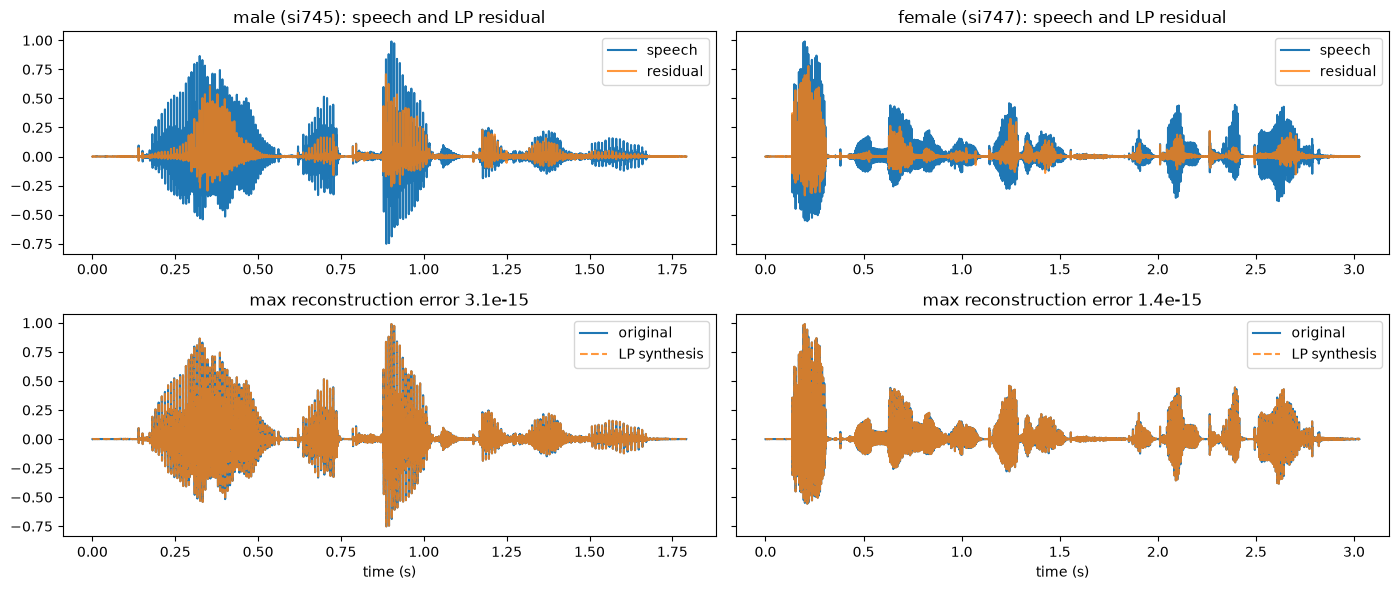

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharey='row')
for col, (name, x) in enumerate(signals.items()):
    residual, coeffs = lp_analysis(x, FRAME, ORDER)
    y = lp_synthesis(residual, FRAME, coeffs)
    t = np.arange(len(x)) / RATE
    axes[0, col].plot(t, x, label='speech'); axes[0, col].plot(t, residual, label='residual', alpha=0.8)
    axes[0, col].set_title(f'{name}: speech and LP residual'); axes[0, col].legend()
    axes[1, col].plot(t, x, label='original'); axes[1, col].plot(t, y, '--', label='LP synthesis', alpha=0.8)
    axes[1, col].set_title(f'max reconstruction error {np.max(np.abs(x - y)):.1e}'); axes[1, col].legend()
    axes[1, col].set_xlabel('time (s)')
fig.tight_layout(); fig.savefig('docs/analysis_synthesis.png', dpi=110)

## 3.3 Quantization of the LP filter

The synthesis filters are converted to lattice (reflection) coefficients and quantized uniformly on (-1, 1) with 5, 4 and 3 bits. Reconstruction levels are the cell centres, so no quantized coefficient reaches ±1 and every quantized filter stays stable.

Spectral distortion: SD² = 1/(N/2+1) Σ (10 log10 Po(i) − 10 log10 Pq(i))², i = 0…N/2.

In [3]:
rows = []
for name, x in signals.items():
    row = {'file': name}
    for bits in (5, 4, 3):
        sds = []
        for start in range(0, len(x) - FRAME + 1, FRAME):
            a, k = levinson(autocorrelation(x[start:start + FRAME], ORDER), ORDER)
            if not np.any(k):  # silent frame
                continue
            sds.append(spectral_distortion(a, lattice_to_lpc(quantize_lattice(k, bits))))
        row[f'{bits} bits'] = round(float(np.mean(sds)), 2)
    rows.append(row)
import pandas as pd
pd.DataFrame(rows).set_index('file').rename_axis('average SD (dB)')

,5 bits,4 bits,3 bits
average SD (dB),,,
male (si745),0.83,1.71,2.79
female (si747),0.82,1.72,3.03


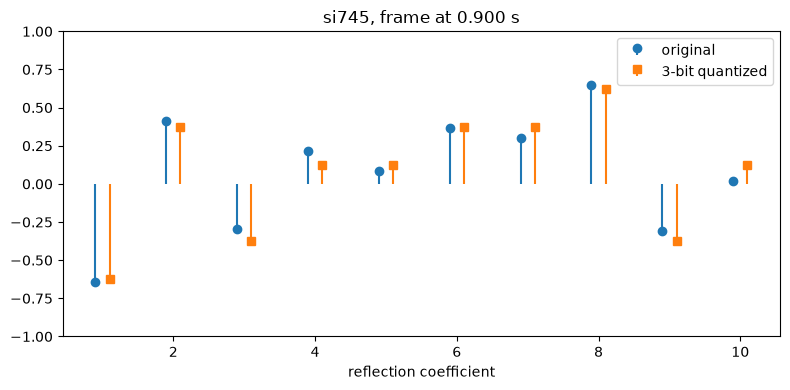

In [4]:
x = signals['male (si745)']
energies = [np.sum(x[s:s + FRAME] ** 2) for s in range(0, len(x) - FRAME + 1, FRAME)]
start = int(np.argmax(energies)) * FRAME  # sustained, high-amplitude frame
_, k = levinson(autocorrelation(x[start:start + FRAME], ORDER), ORDER)
fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(np.arange(1, 11) - 0.1, k, linefmt='C0-', markerfmt='C0o', basefmt=' ', label='original')
ax.stem(np.arange(1, 11) + 0.1, quantize_lattice(k, 3), linefmt='C1-', markerfmt='C1s', basefmt=' ', label='3-bit quantized')
ax.set_xlabel('reflection coefficient'); ax.set_ylim(-1, 1); ax.legend()
ax.set_title(f'si745, frame at {start / RATE:.3f} s')
fig.tight_layout(); fig.savefig('docs/lattice_3bit.png', dpi=110)

Analysis and synthesis with the 3-bit filters: as long as the decoder uses the *same* quantized filter as the encoder, synthesis is still the exact inverse of analysis. Quantizing the filter alone costs nothing in the waveform; the loss only appears once the residual is quantized too (3.4). What changes is the residual, which now carries more of the spectral envelope.

In [5]:
for name, x in signals.items():
    coeffs = []
    for start in range(0, len(x), FRAME):
        _, k = levinson(autocorrelation(x[start:start + FRAME], ORDER), ORDER)
        coeffs.append(lattice_to_lpc(quantize_lattice(k, 3)))
    residual_q, _ = lp_analysis(x, FRAME, ORDER, coeffs)
    residual, _ = lp_analysis(x, FRAME, ORDER)
    y = lp_synthesis(residual_q, FRAME, coeffs)
    gain = 10 * np.log10(np.sum(x**2) / np.sum(residual**2))
    gain_q = 10 * np.log10(np.sum(x**2) / np.sum(residual_q**2))
    print(f'{name}: prediction gain {gain:.1f} dB unquantized, {gain_q:.1f} dB with 3-bit filters; '
          f'max reconstruction error {np.max(np.abs(x - y)):.1e}')

male (si745): prediction gain 9.0 dB unquantized, 8.0 dB with 3-bit filters; max reconstruction error 0.0e+00
female (si747): prediction gain 9.0 dB unquantized, 8.2 dB with 3-bit filters; max reconstruction error 0.0e+00


## 3.4 The codec

Per frame: 3-bit lattice filter, residual low-pass filtered with the 11-tap zero-phase FIR of Table 1, normalised by its (6-bit, log-scale) maximum, decimated by 3 on the grid (of four) with the most energy, and the 66 remaining samples quantized with 3 bits. The encoder writes a real bit stream; the decoder reads it back.

In [6]:
config = CodecConfig()
print('bits per frame:', config.budget(), '=', config.bits_per_frame)
print(f'bit rate: {config.bits_per_frame} bits / {config.frame_ms:g} ms = {config.bit_rate / 1000:.2f} kbit/s '
      f'(input: 128 kbit/s, compression {128000 / config.bit_rate:.1f}x)')

bits per frame: {'LP filter': 30, 'gain': 6, 'grid': 2, 'pulses': 198} = 236
bit rate: 236 bits / 25 ms = 9.44 kbit/s (input: 128 kbit/s, compression 13.6x)


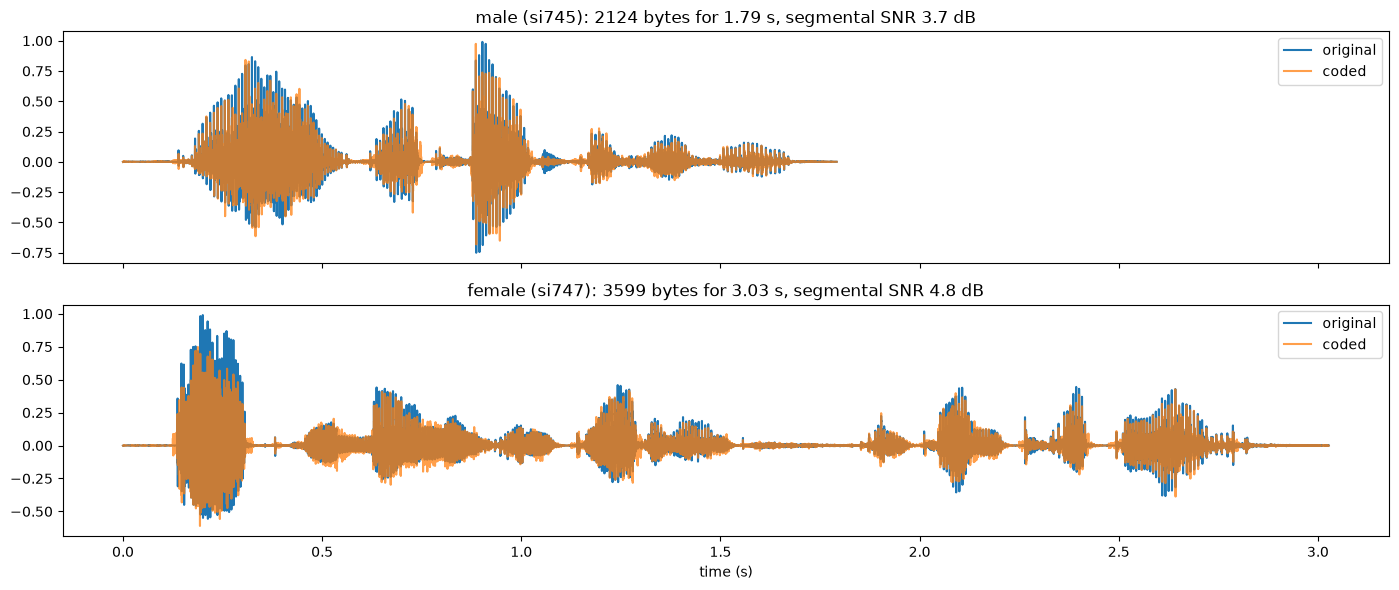

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, (name, x) in zip(axes, signals.items()):
    bitstream, n = encode(x, config)
    y = decode(bitstream, n, config)
    t = np.arange(n) / RATE
    ax.plot(t, x, label='original'); ax.plot(t, y, alpha=0.75, label='coded')
    ax.set_title(f'{name}: {len(bitstream)} bytes for {n / RATE:.2f} s, segmental SNR {segmental_snr_db(x, y):.1f} dB')
    ax.legend(loc='upper right')
axes[-1].set_xlabel('time (s)')
fig.tight_layout(); fig.savefig('docs/codec.png', dpi=110)

Other bit allocations, for comparison (all 20 sentences: `python -m lpcodec --pulse-bits 4`).

In [8]:
for pulse_bits in (2, 3, 4):
    c = CodecConfig(pulse_bits=pulse_bits)
    snrs = [segmental_snr_db(x, decode(*encode(x, c), c)) for x in signals.values()]
    print(f'{pulse_bits} bits/pulse: {c.bit_rate / 1000:5.2f} kbit/s, mean segmental SNR {np.mean(snrs):.1f} dB')

2 bits/pulse:  6.80 kbit/s, mean segmental SNR 0.8 dB
3 bits/pulse:  9.44 kbit/s, mean segmental SNR 4.2 dB


4 bits/pulse: 12.08 kbit/s, mean segmental SNR 5.7 dB


## 4. Subjective evaluation

`python -m lpcodec` writes `output/dcr/*.wav`: each file is the original sentence, 0.5 s of silence and the coded sentence, ready for a degradation category rating (DCR) test.